### 기본 로딩

In [1]:
import pandas as pd

# parquet 경로 (본인 경로에 맞게 수정)
parquet_path = "/root/workspace/h5radiomics/output_test/features/TENX95_features/TENX95_radiomics_features.parquet"

df = pd.read_parquet(parquet_path)

print("shape:", df.shape)
df.head()

shape: (7760, 123)


,patch_idx,barcode,color_path,gray_path,mask_path,x,y,status,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,0,005x028,,,,2616,13425,ok,v3.0.1,1.26.4,...,1.366964,0.370536,0.504167,1.832738,0.172024,8.358824,0.039409,0.181250,0.022160,0.043478
1,1,005x029,,,,2616,13896,ok,v3.0.1,1.26.4,...,0.293056,0.068046,0.467651,14.040366,0.030923,0.633618,0.035935,4.014325,0.024055,1.058344
2,2,005x030,,,,2616,14367,ok,v3.0.1,1.26.4,...,0.300434,0.071423,0.472543,14.163616,0.033959,0.412996,0.055578,2.974109,0.023923,1.425231
3,3,005x031,,,,2616,14837,ok,v3.0.1,1.26.4,...,0.442329,0.073568,0.248589,3.606120,0.022490,0.975616,0.047219,0.713024,0.002494,0.581944
4,4,006x018,,,,3087,8720,ok,v3.0.1,1.26.4,...,0.283704,0.071008,0.409977,6.082315,0.031529,0.967285,0.046981,1.001462,0.002657,0.585922


### 컬럼 구조 확인

In [2]:
print("총 컬럼 수:", len(df.columns))

# 일부 컬럼만 보기
for col in df.columns[:20]:
    print(col)

총 컬럼 수: 123
patch_idx
barcode
color_path
gray_path
mask_path
x
y
status
diagnostics_Versions_PyRadiomics
diagnostics_Versions_Numpy
diagnostics_Versions_SimpleITK
diagnostics_Versions_PyWavelet
diagnostics_Versions_Python
diagnostics_Configuration_Settings
diagnostics_Configuration_EnabledImageTypes
diagnostics_Image-original_Hash
diagnostics_Image-original_Dimensionality
diagnostics_Image-original_Spacing
diagnostics_Image-original_Size
diagnostics_Image-original_Mean


### status 필터링 

In [4]:
# df["status"].value_counts()

print(f"Original: {df.shape}")

df_ok = df[df["status"] == "ok"].copy()
print(f"Filtered: {df_ok.shape}")

Original: (7760, 123)
Filtered: (7756, 123)


### feature 컬럼만 분리

In [5]:
meta_cols = [
    "patch_idx", "barcode",
    "color_path", "gray_path", "mask_path",
    "x", "y", "status"
]

feature_cols = [c for c in df_ok.columns if c not in meta_cols]

features = df_ok[feature_cols]

print("feature shape:", features.shape)
features.head()

feature shape: (7756, 115)


,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,v3.0.1,1.26.4,2.5.3,1.8.0,3.11.15,"{""minimumROIDimensions"": 2, ""minimumROISize"": ...","{""Original"": {}}",20916ae4f2fd3d9dfd04e3877ef55759ca3ea338,2D,"[1.0, 1.0]",...,1.366964,0.370536,0.504167,1.832738,0.172024,8.358824,0.039409,0.181250,0.022160,0.043478
1,v3.0.1,1.26.4,2.5.3,1.8.0,3.11.15,"{""minimumROIDimensions"": 2, ""minimumROISize"": ...","{""Original"": {}}",4ed5d5d8d7eb24fe0979824a560374a5c4d06d6a,2D,"[1.0, 1.0]",...,0.293056,0.068046,0.467651,14.040366,0.030923,0.633618,0.035935,4.014325,0.024055,1.058344
2,v3.0.1,1.26.4,2.5.3,1.8.0,3.11.15,"{""minimumROIDimensions"": 2, ""minimumROISize"": ...","{""Original"": {}}",7b52476f8fea360ca23589ebba765dd9025c9278,2D,"[1.0, 1.0]",...,0.300434,0.071423,0.472543,14.163616,0.033959,0.412996,0.055578,2.974109,0.023923,1.425231
3,v3.0.1,1.26.4,2.5.3,1.8.0,3.11.15,"{""minimumROIDimensions"": 2, ""minimumROISize"": ...","{""Original"": {}}",5b909ec0bc59b530a9725550e9db1ed7960fde98,2D,"[1.0, 1.0]",...,0.442329,0.073568,0.248589,3.606120,0.022490,0.975616,0.047219,0.713024,0.002494,0.581944
4,v3.0.1,1.26.4,2.5.3,1.8.0,3.11.15,"{""minimumROIDimensions"": 2, ""minimumROISize"": ...","{""Original"": {}}",7bd6fcfde2460e2acb721f5402ed6db89dbc4753,2D,"[1.0, 1.0]",...,0.283704,0.071008,0.409977,6.082315,0.031529,0.967285,0.046981,1.001462,0.002657,0.585922


### 기본 통계 확인

In [6]:
features.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
diagnostics_Image-original_Mean,7756.0,1.999950e+02,9.740959e+00,1.589114e+02,1.946723e+02,1.987469e+02,2.032417e+02,2.386957e+02
diagnostics_Image-original_Minimum,7756.0,1.830067e+01,1.995595e+01,0.000000e+00,1.100000e+01,1.300000e+01,1.800000e+01,2.090000e+02
diagnostics_Image-original_Maximum,7756.0,2.523351e+02,2.066717e+00,2.350000e+02,2.510000e+02,2.530000e+02,2.540000e+02,2.550000e+02
diagnostics_Mask-original_VoxelNum,7756.0,3.873875e+04,9.422482e+03,6.100000e+01,3.713150e+04,4.158100e+04,4.441350e+04,4.979200e+04
diagnostics_Mask-original_VolumeNum,7756.0,3.630428e+01,4.654270e+01,1.000000e+00,1.500000e+01,2.600000e+01,4.500000e+01,1.013000e+03
original_firstorder_10Percentile,7756.0,1.568078e+02,1.773379e+01,5.800000e+01,1.490000e+02,1.610000e+02,1.680000e+02,2.143000e+02
original_firstorder_90Percentile,7756.0,2.140427e+02,1.958683e+00,1.970000e+02,2.130000e+02,2.140000e+02,2.150000e+02,2.190000e+02
original_firstorder_Energy,7756.0,1.435979e+09,3.558105e+08,2.830798e+06,1.386992e+09,1.541551e+09,1.645973e+09,1.937033e+09
original_firstorder_Entropy,7756.0,1.744340e+00,2.927166e-01,-3.203427e-16,1.590188e+00,1.731596e+00,1.896288e+00,2.839872e+00
original_firstorder_InterquartileRange,7756.0,2.628810e+01,8.217294e+00,3.000000e+00,2.200000e+01,2.500000e+01,2.900000e+01,1.130000e+02


### 특정 feature 시각화

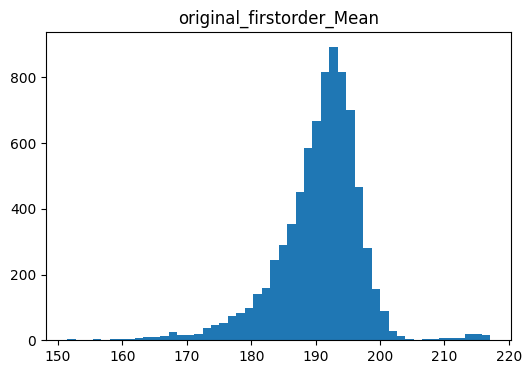

In [7]:
import matplotlib.pyplot as plt

feat = "original_firstorder_Mean"  # 원하는 feature

plt.figure(figsize=(6,4))
plt.hist(features[feat], bins=50)
plt.title(feat)
plt.show()

### 좌표 기반 확인 (공간 확인용)

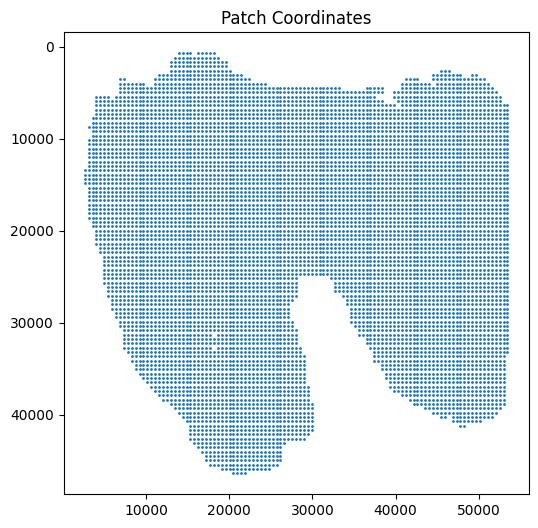

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(df_ok["x"], df_ok["y"], s=1)
plt.title("Patch Coordinates")
plt.gca().invert_yaxis()
plt.show()